In [1]:
import pandas as pd

df = pd.read_csv("worldometer_coronavirus_daily_data.csv")

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()
print("\n--- Statistical Summary ---")
display(df.describe())

--- First 5 Rows ---


,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-2-15,Afghanistan,0.0,NaN,0.0,0.0,NaN
1,2020-2-16,Afghanistan,0.0,NaN,0.0,0.0,NaN
2,2020-2-17,Afghanistan,0.0,NaN,0.0,0.0,NaN
3,2020-2-18,Afghanistan,0.0,NaN,0.0,0.0,NaN
4,2020-2-19,Afghanistan,0.0,NaN,0.0,0.0,NaN



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184787 entries, 0 to 184786
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     184787 non-null  object 
 1   country                  184787 non-null  object 
 2   cumulative_total_cases   184787 non-null  float64
 3   daily_new_cases          174329 non-null  float64
 4   active_cases             166747 non-null  float64
 5   cumulative_total_deaths  178227 non-null  float64
 6   daily_new_deaths         157850 non-null  float64
dtypes: float64(5), object(2)
memory usage: 9.9+ MB

--- Statistical Summary ---


,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
count,1.847870e+05,174329.000000,1.667470e+05,1.782270e+05,157850.000000
mean,7.251089e+05,2987.633285,6.239283e+04,1.388600e+04,39.831834
std,3.681471e+06,17803.232663,3.955641e+05,6.049521e+04,181.102770
min,0.000000e+00,-322.000000,-1.432100e+04,0.000000e+00,-39.000000
25%,1.099000e+03,0.000000,6.000000e+01,2.400000e+01,0.000000
50%,1.775600e+04,58.000000,1.386000e+03,3.040000e+02,1.000000
75%,2.238085e+05,728.000000,1.462050e+04,4.111000e+03,12.000000
max,8.420947e+07,909610.000000,1.793543e+07,1.026646e+06,5093.000000


In [2]:
print("--- Missing Values ---")
print(df.isnull().sum())

df_cleaned = df.dropna()

print(f"\nDuplicates found: {df.duplicated().sum()}")

--- Missing Values ---
date                           0
country                        0
cumulative_total_cases         0
daily_new_cases            10458
active_cases               18040
cumulative_total_deaths     6560
daily_new_deaths           26937
dtype: int64

Duplicates found: 0


In [3]:
highest_deaths = df.sort_values('cumulative_total_deaths', ascending=False).head(1)
print("Country with Highest Deaths:")
print(highest_deaths[['country', 'cumulative_total_deaths']])

country_deaths = df.groupby('country')['cumulative_total_deaths'].max()
print("\nTotal Deaths per Country (Top 10):")
print(country_deaths.sort_values(ascending=False).head(10))

Country with Highest Deaths:
       country  cumulative_total_deaths
177406     USA                1026646.0

Total Deaths per Country (Top 10):
country
USA          1026646.0
Brazil        664920.0
India         524214.0
Russia        377571.0
Mexico        324465.0
Peru          213023.0
UK            176708.0
Italy         165182.0
Indonesia     156453.0
France        147257.0
Name: cumulative_total_deaths, dtype: float64


Interpretation:  
Trends Observed: "The cumulative data shows a steady increase in cases over time across all continents, with major spikes during specific variants."   

Zero Recoveries: "In this specific Worldometer dataset, recovery data might be missing or not reported by certain countries, leading to zero or null values."

Impact of Missing Data: "Missing values in daily new cases can skew the growth rate analysis and make it difficult to predict future trends accurately."

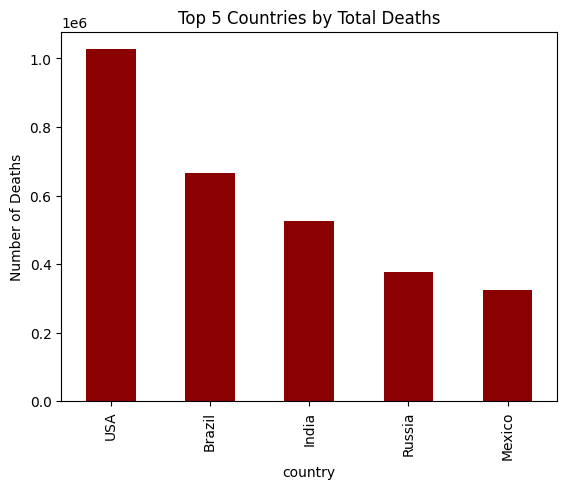

In [4]:
import matplotlib.pyplot as plt

country_deaths.sort_values(ascending=False).head(5).plot(kind='bar', color='darkred')
plt.title('Top 5 Countries by Total Deaths')
plt.ylabel('Number of Deaths')
plt.show()